# Homework 4 General comment
In HW #4 we'll ask you to produce a little bit more code than in previous exercise sets. This will require you to check the outputs more carefully, too. Feel free to use the many examples we've done in class.

# Exercise 1: Transformer Classifier for Kinematics (30 points)

Suppose a ball is launched from the origin with some initial velocity. You observe 10 noisy position measurements $(x, y)$ during the first half of the flight.

Your task is to predict whether the ball will land to the left ($x < 0$) or to the right ($x > 0$) of the origin.

Before you start, review these items (no need to write the answer):
- What do the Q, K, V projections do?
- What does `nn.TransformerEncoderLayer` contain in terms of parameters and structure?
- Why does positional encoding matter for ordered sequences?

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cpu")  # this problem is tiny, CPU is fine
print("Ready!")

Ready!


## Generate the data

Each trajectory follows projectile motion:

$$x(t) = v_{x0}\, t, \qquad y(t) = v_{y0}\, t - \tfrac{1}{2}g\,t^2$$

We add Gaussian noise to simulate measurement uncertainty.
The label is 1 if the ball lands at $x > 0$ (right) or 0 if $x < 0$ (left).


In [13]:
G = 9.8           # gravity
N_STEPS = 10      # measurements per trajectory
NOISE = 0.3       # measurement noise (meters)

def make_trajectory():
    """Generate one noisy trajectory and a left/right label."""
    vx = np.random.uniform(-5, 5)      # horizontal velocity
    vy = np.random.uniform(5, 15)      # upward velocity
    t_flight = 2 * vy / G              # total flight time

    # Observe only the FIRST HALF of the flight
    t = np.linspace(0, t_flight * 0.5, N_STEPS)
    x = vx * t + np.random.normal(0, NOISE, N_STEPS)
    y = vy * t - 0.5 * G * t**2 + np.random.normal(0, NOISE, N_STEPS)

    # Where does it actually land?
    x_land = vx * t_flight
    label = 1 if x_land > 0 else 0     # 1=right, 0=left

    # Each time step is one transformer token: (x, y)
    sequence = np.stack([x, y], axis=1).astype(np.float32)
    return sequence, label, x_land


def make_dataset(n):
    """Generate n trajectories, return as tensors."""
    seqs, labels = [], []
    for _ in range(n):
        s, l, _ = make_trajectory()
        seqs.append(s)
        labels.append(l)
    return torch.tensor(np.array(seqs)), torch.tensor(labels)

X_train, y_train = make_dataset(4000)
X_val, y_val     = make_dataset(1000)

print(f"X_train shape: {X_train.shape}  -- (samples, time_steps, features)")
print(f"y_train shape: {y_train.shape}  -- (samples,)")
print(f"\nEach sample: {N_STEPS} time steps, each with 2 features (x, y)")
print(f"Labels: 0=left, 1=right")
print(f"Class balance: left={int((y_train==0).sum())}, right={int((y_train==1).sum())}")

X_train shape: torch.Size([4000, 10, 2])  -- (samples, time_steps, features)
y_train shape: torch.Size([4000])  -- (samples,)

Each sample: 10 time steps, each with 2 features (x, y)
Labels: 0=left, 1=right
Class balance: left=1925, right=2075


### Visualize the trajectories

This should give you some idea of the data you will be using. You can see that the first step in the trajectory may be to the left even though the ball eventually ends up to the right.

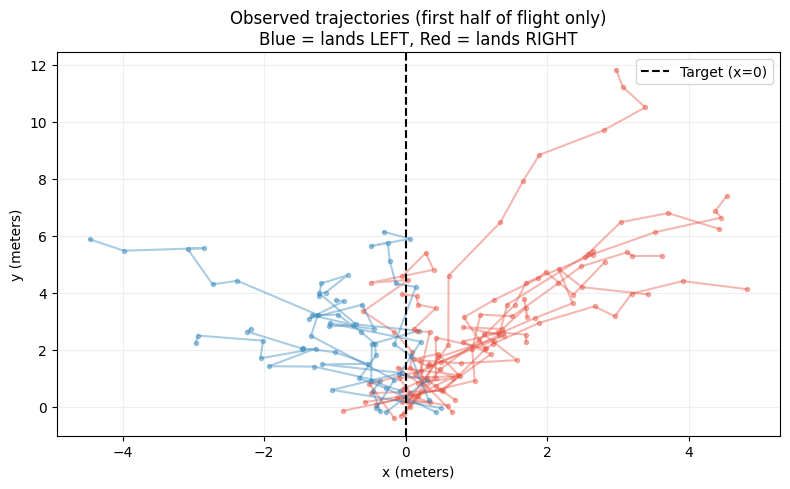

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(20):
    seq, label, x_land = make_trajectory()
    color = "#2980b9" if label == 0 else "#e74c3c"
    ax.plot(seq[:, 0], seq[:, 1], "o-", color=color, alpha=0.4, markersize=3)

ax.axvline(0, color="k", ls="--", label="Target (x=0)")
ax.set_xlabel("x (meters)"); ax.set_ylabel("y (meters)")
ax.set_title("Observed trajectories (first half of flight only)\n"
             "Blue = lands LEFT, Red = lands RIGHT")
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# part 1(a): Build the Transformer Model (10 points)

Write your own code to complete the `TrajectoryClassifier` class below.

Your model should include the following two functions:

`__init__` -- define these layers:
- `self.embed`: an `nn.Linear` that projects each $(x, y)$ pair (2 features) up to `d_model` dimensions
- `self.pos`: a learnable positional encoding: `nn.Parameter(torch.randn(1, N_STEPS, d_model) * 0.1)`
- `self.transformer`: a `nn.TransformerEncoder` built from `nn.TransformerEncoderLayer`. Use `batch_first=True` and `dim_feedforward=64`
- `self.classifier`: an `nn.Linear` that maps from `d_model` to `n_classes`

`forward(self, x)` where `x` has shape `(batch, 10, 2)`:
- Embed: `x = self.embed(x)` to make the shape `(batch, 10, d_model)`
- Add positional encoding: `x = x + self.pos`
- Transformer: `x = self.transformer(x)`
- Average pool over time: `x = x.mean(dim=1)` to make the shape `(batch, d_model)`
- Classify: `return self.classifier(x)`

In [15]:
class TrajectoryClassifier(nn.Module):

    def __init__(self, input_dim=2, d_model=32, n_heads=2, n_layers=2, n_classes=2):
        super().__init__()

        # Define: self.embed, self.pos, self.transformer, self.classifier
        ## project each (x, y) pair from 2D to d_model dimensions
        self.embed = nn.Linear(input_dim, d_model)

        ## tells the model which time step each token is
        self.pos = nn.Parameter(torch.randn(1, N_STEPS, d_model) * 0.1)

        ## build transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=64, batch_first=True)

        ## stack n layers of those blocks together
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        ## map from d_model to n_classes
        self.classifier = nn.Linear(d_model, n_classes)


    def forward(self, x):
        """x: (batch, 10, 2) -- sequence of (x, y) measurements"""

        # Steps: embed -> add pos -> transformer -> mean pool -> classify
        x = self.embed(x)
        x = x + self.pos
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)





### Unit tests

You can run this cell to check your code.
- Is `forward()` complete?
- Does the output have the correct shape?

In [16]:
# -- Sanity checks (do not modify) --
try:
    _test_model = TrajectoryClassifier()
    _test_input = torch.randn(4, N_STEPS, 2)
    _test_output = _test_model(_test_input)

    assert _test_output is not None, "forward() returned None -- did you forget the return statement?"
    assert _test_output.shape == (4, 2), f"Expected shape (4, 2), got {_test_output.shape}"

    _n = sum(p.numel() for p in _test_model.parameters())
    print(f"Output shape: {_test_output.shape}  [correct]")
    print(f"Parameters:   {_n:,}")
    print("\nAll checks passed!")

except Exception as e:
    print(f"ERROR: {e}")
    print("\nGo back and check your model.")

Output shape: torch.Size([4, 2])  [correct]
Parameters:   17,570

All checks passed!


PART A: all checks passed!

## part 1(b): Write the Training Loop (10 points)

Write a training loop that:
1. Creates a `TrajectoryClassifier` and stores it in a variable called `model`
2. Creates an `Adam` optimizer with learning rate `1e-3`
3. Creates a cross-entropy loss function (`nn.CrossEntropyLoss()`)
4. Trains for 30 epochs. In each epoch:
   - Set the model to training mode (`model.train()`)
   - Zero the gradients
   - Compute logits by passing `X_train` through the model
   - Compute the loss between logits and `y_train`
   - Backpropagate and update weights
   - Set the model to eval mode (`model.eval()`) and compute validation accuracy in the usual way:
     ```python
     with torch.no_grad():
         val_logits = model(X_val)
         val_acc = (val_logits.argmax(dim=1) == y_val).float().mean().item()
     ```
5. Store the training loss in a list called `train_losses` and the validation accuracy in a list called `val_accs`
6. Print the loss and accuracy every 5 epochs

These two lists (`train_losses` and `val_accs`) are used by later cells,
so make sure you name them correctly.


In [17]:
# Create: model, optimizer, criterion
# Lists:  train_losses = [], val_accs = []
# Loop:   30 epochs of training + validation
# Print:  every 5 epochs
#
# Expected output: validation accuracy should reach ~85-95%

## create model
model = TrajectoryClassifier().to(DEVICE)

## create optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## cross-entropy loss
criterion = nn.CrossEntropyLoss()

## lists to track progress
train_losses = []
val_accs = []

## training loop, 30 epochs
for epoch in range(1,31):

  ## training
  model.train()
  optimizer.zero_grad()       ## clear gradients from last step
  logits = model(X_train)     ## forward pass -> shape (4000, 2)
  loss = criterion(logits, y_train)     ## compare predictions
  loss.backward()             ## backpropagate gradients
  optimizer.step()          ## update weights

  ## store training loss as python float
  train_losses.append(loss.item())

  ## validation
  model.eval()
  with torch.no_grad():
    val_logits = model(X_val)
    ## argmax picks class with higher score
    val_acc = (val_logits.argmax(dim=1) == y_val).float().mean().item()

  val_accs.append(val_acc)

  ## print every 5 epochs
  if epoch % 5 == 0:
    print(f"Epoch {epoch:3d} | Loss: {loss.item():.3f} | Val Acc: {val_acc*100:.1f}%")



Epoch   5 | Loss: 0.640 | Val Acc: 83.7%
Epoch  10 | Loss: 0.445 | Val Acc: 94.5%
Epoch  15 | Loss: 0.261 | Val Acc: 97.3%
Epoch  20 | Loss: 0.139 | Val Acc: 98.5%
Epoch  25 | Loss: 0.079 | Val Acc: 98.6%
Epoch  30 | Loss: 0.055 | Val Acc: 98.5%


PART B: accuracy goes up and loss goes down as epochs continue, meaning it seems to be working well

## part 1(c): Plot the Training Curves (10 points)

Plot the following training curves:
- training loss vs. epoch (use your `train_losses` list)
- validation accuracy (%) vs. epoch (use your `val_accs` list). Draw a dashed horizontal line at 50% to show random chance.

Dont' forget to label the axes, add some titles, and add a legend to the validation accuracy plot.

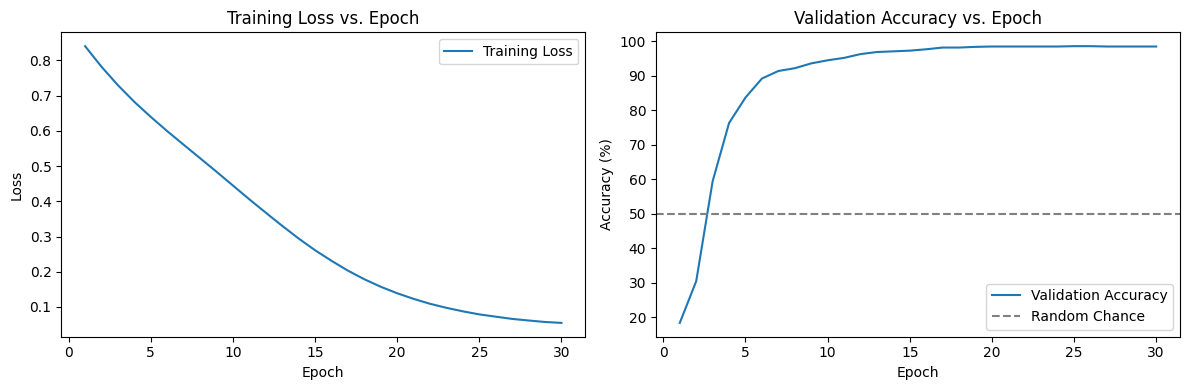

In [18]:
# Plot these two training curves:
# - training loss vs epoch
# - validation accuracy (%) vs epoch, with a 50% baseline


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, 31)     ## x-axis: epochs 1 through 30

## training loss
ax1.plot(epochs, train_losses, label="Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss vs. Epoch")
ax1.legend()

## validation accuracy
val_accs_percent = [v * 100 for v in val_accs]
ax2.plot(epochs, val_accs_percent, label="Validation Accuracy")

## line at 50% (random chance for left/right)
ax2.axhline(50, ls="--", color="gray", label="Random Chance")

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Validation Accuracy vs. Epoch")
ax2.legend()

plt.tight_layout()
plt.show()


PART C: the plots show that the model is learning well. the loss goes down as the validation accuracy goes up, which is exactly what we want

# Exercise 2: autoencoder for anomaly detection  (40 points)

In this exercise you will train a nonlinear autoencoder and use it for anomaly detection. The idea is straightforward: train the autoencoder only on "normal" stars in a SDSS stellar photometry dataset.

When you then feed the autoencoder an unusual star, it reconstructs it poorly because it has no compact code for that type of object.
The reconstruction error $\|x - \hat{x}\|^2$ therefore serves as an anomaly score. High values of anomaly score indicate an outlier with respect to the training data.

There are three specific parts where you will need to write code to complete the exercise.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

## Load dataset

The SDSS dataset is in the file `sspp_colors.npz`. You can put it in the same directory as this notebook. (In Colab, click on the Folder icon at left to upload it.)

For each star we have
- colors: photometric strength in u-g, g-r, r-i, and i-z wavelength bands
- $T_\text{eff}$: effective temperature [K]
- $\log g$: base-10 logarithm of the surface gravity
- Fe/H: iron abundance of the star relative to the Sun


In [20]:
npz = np.load('sspp_colors.npz')
colors       = npz['colors'].astype(np.float32)
Teff         = npz['Teff'].astype(np.float32)
logg         = npz['logg'].astype(np.float32)
FeH          = npz['FeH'].astype(np.float32)

print(f'Total stars: {len(colors):,}')
print(f'Teff:   {Teff.min():.0f} - {Teff.max():.0f} K')
print(f'logg:   {logg.min():.2f} - {logg.max():.2f}')
print(f'[Fe/H]: {FeH.min():.2f} - {FeH.max():.2f}')

FileNotFoundError: [Errno 2] No such file or directory: 'sspp_colors.npz'

Now we assign labels to define which stars are "normal" and which are anomalies. These labels are derived from spectroscopy, and the autoencoder will never see them during training. We use them only to construct the training set and to evaluate the anomaly detector afterwards. (These labels are kind of the "solutions" to the problem.)

- Normal: main-sequence FGK dwarfs, $4500 \leq T_\text{eff} \leq 7000$ K and $\log g \geq 3.5$
- Giants: evolved stars with $\log g < 3.0$ and $T_\text{eff} < 5500$ K
- Metal-poor: ancient halo stars with [Fe/H] $< -1.5$

It is useful to notice that the normal and giants have similar values for $T_\text{eff}$. This will be important later.

In [ ]:
normal_mask    = (Teff >= 4500) & (Teff <= 7000) & (logg >= 3.5)
giant_mask     = (logg < 3.0) & (Teff < 5500)
metalpoor_mask = (FeH < -1.5)
anomaly_mask   = giant_mask | metalpoor_mask
normal_mask    = normal_mask & ~anomaly_mask   # remove any overlap

print(f'Normal (main-sequence FGK): {normal_mask.sum():,}')
print(f'Giants:                     {giant_mask.sum():,}')
print(f'Metal-poor:                 {metalpoor_mask.sum():,}')

You should see 196,767 normal stars, along with 17,779 giants and 65,263 metal-poor stars.

### Create DataLoaders and visualize data

We fit the `StandardScaler` on normal training stars only. Fitting on the full dataset would allow information about the anomaly distribution to leak into the preprocessing.

In [ ]:
X_normal  = colors[normal_mask]
X_giants  = colors[giant_mask]
X_metpoor = colors[metalpoor_mask]

scaler = StandardScaler()
X_normal_scaled  = scaler.fit_transform(X_normal)
X_giants_scaled  = scaler.transform(X_giants)
X_metpoor_scaled = scaler.transform(X_metpoor)

N       = len(X_normal_scaled)
n_train = int(0.8 * N)
perm    = np.random.permutation(N)
X_train = X_normal_scaled[perm[:n_train]]
X_test  = X_normal_scaled[perm[n_train:]]

print(f'Training (normal):  {len(X_train):,}')
print(f'Test (normal):      {len(X_test):,}')
print(f'Giants:             {len(X_giants_scaled):,}')
print(f'Metal-poor:         {len(X_metpoor_scaled):,}')

Stars are often plotted in a diagram called the Hertzsprung-Russell diagram that groups them into classes based on $T_\text{eff}$ and $\log g$.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(Teff, logg, s=0.3, color='lightgray')
ax.scatter(Teff[normal_mask],    logg[normal_mask],
           s=0.5, color='steelblue',
           label=f'Normal ({normal_mask.sum():,})')
ax.scatter(Teff[giant_mask],     logg[giant_mask],
           s=3, color='tomato',
           label=f'Giants ({giant_mask.sum():,})')
ax.scatter(Teff[metalpoor_mask], logg[metalpoor_mask],
           s=3, color='gold',
           label=f'Metal-poor ({metalpoor_mask.sum():,})')
ax.set_xlabel(r'$T_{\mathrm{eff}}$ (K)')
ax.set_ylabel(r'$\log g$')
ax.set_title('Populations in the H-R Diagram')
ax.invert_xaxis()
ax.invert_yaxis()
ax.legend(markerscale=5, loc='lower left')
plt.tight_layout()
plt.show()

*Prediction time!*

Look at the H-R diagram above. The autoencoder will be trained only on the blue points and will never see the physical labels. Its only input is the four photometric color strengths u-g, g-r, r-i, i-z.

Which anomaly type do you expect the autoencoder to detect more easily — red giants or metal-poor halo stars? Justify your prediction in physical terms. Think about what separates each population from normal stars in color space, and about what broadband photometry can and cannot distinguish.

You don't have to write down your answer yet, but keep it in mind for part 2(d).

Now let's get to work.


## part 2(a): autoencoder architecture (10 points)

Complete the autoencoder architecture by completing the encoder and decoder `nn.Sequential` stacks below using `nn.Linear` and `nn.ReLU` layers.

Two things to keep in mind:
- ReLU always goes between linear layers, not after the final one in each stack
- The decoder output layer must have no activation function, because the reconstruction is a real-valued vector that should not be transformed or "logicalized."

A correct implementation has 470 trainable parameters. The check at the bottom of the cell will confirm this.

```
Encoder:  4  ->  16  ->  8  ->  2     (ReLU after each hidden layer)
Decoder:  2  ->  8   ->  16 ->  4     (ReLU after each hidden layer, no activation on output)
```

In [ ]:
class NonlinearAutoencoder(nn.Module):
    def __init__(self, input_dim=4, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            # YOUR CODE HERE
            # input_dim -> 16 -> 8 -> latent_dim, ReLU after first two layers
        )

        self.decoder = nn.Sequential(
            # YOUR CODE HERE
            # latent_dim -> 8 -> 16 -> input_dim, ReLU after first two layers, no final activation
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)


model    = NonlinearAutoencoder(input_dim=4, latent_dim=2)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {n_params}')  # Expected: 470

## part 2(b): write training loop (10 points)

The `DataLoader`, loss function, and optimizer are set up below. Fill in the five standard steps of a PyTorch training iteration inside the batch loop. You may want to look back to examples from class.

Recall that the autoencoder is an unsupervised model: the goals is to get the reconstructed output to match the input. The input is the target!

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader   = DataLoader(
    TensorDataset(X_train_tensor, X_train_tensor),
    batch_size=512, shuffle=True
)

criterion    = nn.MSELoss()
optimizer    = optim.Adam(model.parameters(), lr=0.001)
loss_history = []

model.train()
# You can change the number of epochs if you like, but this works.
for epoch in range(150):
    epoch_loss = 0.0
    for x_batch, target_batch in train_loader:
        # YOUR CODE HERE
        # 1. Zero the gradients
        # 2. Forward pass
        # 3. Compute loss
        # 4. Backward pass
        # 5. Update weights
        pass
        epoch_loss += loss.item() * len(x_batch)

    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch+1:4d}/150  |  Loss: {epoch_loss:.6f}')

In [ ]:
# Run this to plot the training loss curve as function of epoch
# You have written this code many times already.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color='steelblue', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Nonlinear Autoencoder Training Loss')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## part 2(c): anomaly detection (10 points)

To define the anomaly score, we need to write a function called `reconstruction_error(model, X)` that:
- Converts `X` (numpy array, shape `(N, 4)`) to a PyTorch tensor
- Passes it through the model in evaluation mode using `torch.no_grad()`
- Returns a numpy array of shape `(N,)` with the per-sample squared error $\|x_i - \hat{x}_i\|^2 = \sum_{j=1}^4 (x_{ij} - \hat{x}_{ij})^2$

Compute and print the mean and standard deviation for the normal test set, the giants, and the metal-poor stars.

In [ ]:
def reconstruction_error(model, X):
    """
    Parameters
    ----------
    model : NonlinearAutoencoder
    X     : np.ndarray, shape (N, 4)

    Returns
    -------
    errors : np.ndarray, shape (N,)
    """
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        X_hat = model(X_tensor).numpy()
    return np.sum((X - X_hat) ** 2, axis=1)


err_normal  = reconstruction_error(model, X_test)
err_giants  = reconstruction_error(model, X_giants_scaled)
err_metpoor = reconstruction_error(model, X_metpoor_scaled)

print('Mean reconstruction error +/- std:')
print(f'  Normal:      {err_normal.mean():.5f} +/- {err_normal.std():.5f}')
print(f'  Giants:      {err_giants.mean():.5f} +/- {err_giants.std():.5f}')
print(f'  Metal-poor:  {err_metpoor.mean():.5f} +/- {err_metpoor.std():.5f}')

Now you can plot the anomaly score distributions for each class with the provided code. The normal stars cannot be anomalous because they were the training data!

In [ ]:
all_errors = np.concatenate([err_normal, err_giants, err_metpoor])
xmax = np.percentile(all_errors, 99)
bins = np.linspace(0, xmax, 80)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    ax.hist(err_normal,  bins=bins, density=True, alpha=0.5,
            color='steelblue', label='Normal (test)')
    ax.hist(err_giants,  bins=bins, density=True, alpha=0.5,
            color='tomato',    label='Giants')
    ax.hist(err_metpoor, bins=bins, density=True, alpha=0.5,
            color='gold',      label='Metal-poor')
    ax.set_xlabel(r'Reconstruction error $\|x - \hat{x}\|^2$')
    ax.set_ylabel('Density')
    ax.set_yscale(yscale)
    ax.set_title(f'Anomaly Score Distribution ({yscale} scale)')
    ax.legend()

plt.tight_layout()
plt.show()

We might identify anomalous stars (not normal stars) with reconstruction error scores near 1. If we make that the "target" purely for the purposes of comparison, then we can plot a ROC curve and calculate AUC.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for err_anom, label, color in [
        (err_giants,  'Giants',     'tomato'),
        (err_metpoor, 'Metal-poor', 'goldenrod')]:

    scores = np.concatenate([err_normal, err_anom])
    y_true = np.concatenate([np.zeros(len(err_normal)), np.ones(len(err_anom))])
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{label}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: Autoencoder Anomaly Detection')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## part 2(d): comparison (5 points)

Return to your prediction from the beginning of this exercise: "which anomaly type will the autoencoder detect more easily?" Was your prediction correct?

Now, after looking at the ROC curves, answer again: which anomaly type — giants or metal-poor stars — is more easily detected? Give a physical explanation of the result. (*Hint*: a red giant and a cool main-sequence dwarf are at the same $T_\text{eff}$ — how different do they look in u-g, g-r, r-i, i-z?)


## part 2(e): performance of non-linear vs. linear autoencoders (5 points)

What if you replaced the nonlinear autoencoder above with a linear autoencoder, keeping everything else the same?
Would you expect the anomaly detection AUC to be higher, lower, or similar?
Justify your answer by connecting to the mathematical properties of the two models (and perhaps to PCA).


# Exercise 3: Restricted Boltzmann Machines (30 points)

A Restricted Boltzmann Machine with visible units $\mathbf{v} = \{v_i\}$ and hidden units $\mathbf{h} = \{h_j\}$ is defined by the energy function

$$E(\mathbf{v}, \mathbf{h}) = - \sum_i a_i v_i - \sum_j b_j h_j - \sum_{i,j} v_i W_{ij} h_j$$

where $a_i$ and $b_j$ are biases and $W_{ij}$ are the weights.

## part 3(a): Joint probabilities (10 points)

Write down the joint probability $P(\mathbf{v}, \mathbf{h})$ in terms of $E(\mathbf{v}, \mathbf{h})$ and identify the physical quantity that plays the role of the partition function $Z$.

## part 3(b): gradients for RBM (10 points)

The log-likelihood gradient for the RBM with respect to a weight $W_{ij}$ is
$$\frac{\partial}{\partial W_{ij}} \log P(\mathbf{v}_{(\text{data})}) = \langle v_i h_j \rangle_{\text{data}} - \langle v_i h_j \rangle_{\text{model}}$$
where the first expectation is over the data distribution (with $\mathbf{h}$ sampled given $\mathbf{v}^{(\text{data})}$) and the second is over the full model distribution.

Why is the second term $\langle v_i h_j \rangle_{\text{model}}$ computationally intractable to evaluate exactly for a large RBM? (*Hint*: think about what summing over all configurations entails.)

## part 3(c): features in RBM (10 points)

After training an RBM on a dataset of images (e.g., handwritten digits), each hidden unit $h_j$ has an associated weight vector $W_{:j} = \{W_{ij}\}$ over all visible pixels.

The quantity $P(h_j = 1 | \mathbf{v})$ is exactly equal to $\sigma\left(b_j + \sum_i W_{ij} v_i\right)$, where $\sigma$ is the logistic sigmoid. Interpret this equality: what is $h_j$ "detecting" in the visible input $\mathbf{v}$?


------
PART A:

$Z$ is the partition function that normalized the distribution so that all probabilities sum to 1. it is defined by summing over all possible configurations of both visible and hidden units:

$$Z = \sum_{\mathbf{v}} \sum_{\mathbf{h}} e^{-E(\mathbf{v}, \mathbf{h})}$$

so, by substituting in $E(\mathbf{v}, \mathbf{h})$, we get:

$$P(\mathbf{v}, \mathbf{h}) = \frac{1}{Z} \exp\!\left(\sum_i a_i v_i + \sum_j b_j h_j + \sum_{i,j} v_i W_{ij} h_j\right)$$


------
PART B:

the second term is:

$$\langle v_i h_j \rangle_{\text{model}} = \sum_{\mathbf{v}} \sum_{\mathbf{h}} v_i h_j \, P(\mathbf{v}, \mathbf{h}),$$

where $P(\mathbf{v}, \mathbf{h}) = \frac{1}{Z} e^{-E(\mathbf{v}, \mathbf{h})}$.

however, computing this exactly requires summing over ALL possible configurations of both visible and hidden units. but this means there are $2^{n_v + n_h}$ total configurations. even if there were $n_v = 100$ visible and $n_h = 100$ hidden units, this means
evaluating $2^{200} \approx 10^{60}$ terms, which would be a huge computation. so, approximations that estimate using sampling instead of actually summing all configurations makes much more sense.

------
PART C:

the conditional probability of the hidden unit $h_j$ being active is:

$$P(h_j = 1 \mid \mathbf{v}) = \sigma\!\left(b_j + \sum_i W_{ij} v_i\right)$$

where $\sigma(x) = \frac{1}{1 + e^{-x}}$ is the logistic sigmoid.

the term inside the sigmoid is a dot product between the weight vector $W_{j} = \{W_{ij}\}$
and the visible input $\mathbf{v}$, shifted by bias $b_j$. so this means it is computing how much the input $\mathbf{v}$
matches the pattern encoded in $W_{j}$. it is kind of like a feature detector, where it learns to activate in response to a specific structure or pattern in the visible input
